In [1]:
import kagglehub

path = kagglehub.dataset_download("chetankv/dogs-cats-images")

print("Path to dataset files:", path)


100%|██████████| 435M/435M [00:05<00:00, 84.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/chetankv/dogs-cats-images/versions/1


In [2]:
import tensorflow as tf
print(tf.version.VERSION)
print("Dispositivos disponibles:", tf.config.list_physical_devices('GPU'))

2.19.0
Dispositivos disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
path = path + '/dataset'
os.listdir(path)

['training_set', 'test_set']

Separar imágenes de entrenamiento, validación y test

In [15]:
train_dir = os.path.join(path, 'training_set')
test_dir = os.path.join(path, 'test_set')

In [12]:
import tensorflow as tf

BATCH_SIZE = 32
IMAGE_SIZE = 150

# Dividiremos el dataset de entrenamiento y asignamos un 80% a validación
train_ds,validation_ds = tf.keras.utils.image_dataset_from_directory(
  train_dir,
  validation_split=0.2, # 20% validación
  subset="both", # devolvemos ambos datasets resultantes (train,validation)
  seed=123,
  batch_size=BATCH_SIZE)

# test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_dir,
  seed=1234,
  shuffle=False,
  batch_size=BATCH_SIZE)


Found 8000 files belonging to 2 classes.
Using 6400 files for training.
Using 1600 files for validation.
Found 2000 files belonging to 2 classes.


In [16]:
class_names = train_ds.class_names
class_names # Imprimimos clases (labels) de imágenes encontradas

['cats', 'dogs']

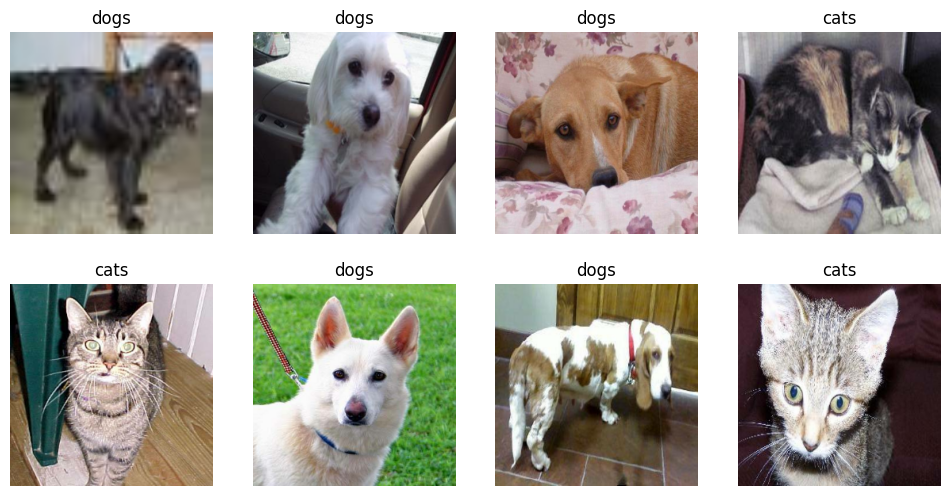

In [14]:
image_batch, label_batch = next(iter(train_ds)) # Obtenemos el primer lote de imágenes (32)

from matplotlib import pyplot as plt
plt.figure(figsize=(12, 6))
for i in range(8):  # Mostramos las 8 primeras imágenes del lote
  ax = plt.subplot(2, 4, i + 1)
  plt.imshow(image_batch[i].numpy().astype("uint8"))
  label = label_batch[i]
  plt.title(class_names[label])
  plt.axis("off")

## Construyendo el modelo

In [33]:
# Cada vez que hagamos cambios en el modelo, debemos ejecutar esto primero
tf.keras.backend.clear_session()

In [34]:
from tensorflow.keras.applications import MobileNetV2

# include_top=False no incluye la capa final densa
mobilenet_base_model = MobileNetV2(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, )
mobilenet_base_model.summary()

/tmp/ipython-input-57550155.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_base_model = MobileNetV2(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Resizing, Rescaling, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, RandomRotation, RandomTranslation, RandomZoom, RandomFlip, BatchNormalization

# define model
model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)), # Define los datos de entrada
    Resizing(IMAGE_SIZE, IMAGE_SIZE), # Integramos el escalado de las imágenes en el modelo
    Rescaling(1./255), # Normalizamos en el modelo

    mobilenet_base_model,

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(1, activation='sigmoid') # La clasificación es binaria
])

In [37]:
# compile model
model.compile(optimizer = tf.optimizers.Adam(),
    loss = 'binary_crossentropy', # Función de pérdida en clasificación binaria
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,192,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451,521 (39.87 MB)

 Trainable params: 10,416,897 (39.74 MB)

 Non-trainable params: 34,624 (135.25 KB)

In [38]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# Monitoreamos la pérdida en la validación. Detenemos después de 6 iteraciones sin mejorar. Restauramos mejores pesos
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',   # Monitorea la pérdida en validación
    factor=0.5,           # Reduce la tasa de aprendizaje a la mitad
    patience=3,           # Espera 3 iteraciones sin mejora antes de reducir
    min_lr=1e-6           # No permite que la tasa de aprendizaje baje de 1e-6
)

# Pipeline optimizado y sin Warnings
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .ignore_errors() # Nueva versión
    .prefetch(buffer_size=AUTOTUNE)
)

validation_ds = (
    validation_ds
    .ignore_errors() # Nueva versión
    .prefetch(buffer_size=AUTOTUNE)
)

history = model.fit(train_ds,
        epochs = 30,
        validation_data=(validation_ds),
        callbacks=[early_stop, reduce_lr]  # Agregar ambas estrategias
)

Epoch 1/30
    200/Unknown 69s 64ms/step - accuracy: 0.8667 - loss: 0.3760

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


200/200 ━━━━━━━━━━━━━━━━━━━━ 77s 101ms/step - accuracy: 0.8668 - loss: 0.3753 - val_accuracy: 0.8381 - val_loss: 2.6541 - learning_rate: 0.0010
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.9456 - loss: 0.1388 - val_accuracy: 0.6212 - val_loss: 5.2446 - learning_rate: 0.0010
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.9477 - loss: 0.1289 - val_accuracy: 0.8500 - val_loss: 1.1029 - learning_rate: 0.0010
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.9644 - loss: 0.0837 - val_accuracy: 0.8619 - val_loss: 1.1880 - learning_rate: 0.0010
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.9758 - loss: 0.0629 - val_accuracy: 0.6100 - val_loss: 4.1488 - learning_rate: 0.0010
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - accuracy: 0.9778 - loss: 0.0694 - val_accuracy: 0.8025 - val_loss: 1.8265 - learning_rate: 0.0010
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - accuracy: 0.9866 - loss: 0.037

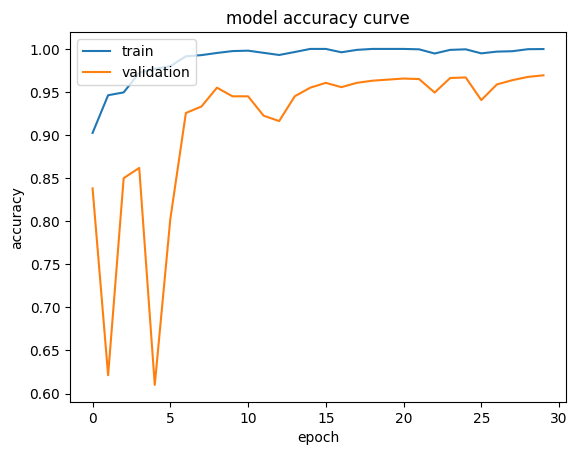

In [39]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy curve')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

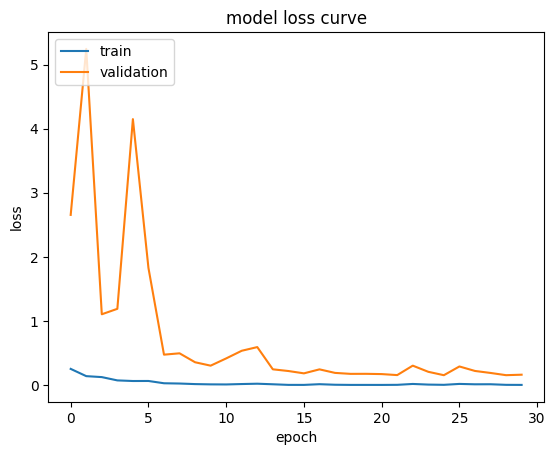

In [40]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss curve')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [41]:
# Aplicamos la misma lógica para que no se detenga el proceso
test_ds_limpio = test_ds.ignore_errors().prefetch(buffer_size=tf.data.AUTOTUNE)

# Ahora evaluamos
results = model.evaluate(test_ds_limpio)
print(f"Loss: {results[0]}, Accuracy: {results[1]}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 202ms/step - accuracy: 0.9704 - loss: 0.1299
Loss: 0.1318233609199524, Accuracy: 0.9704999923706055


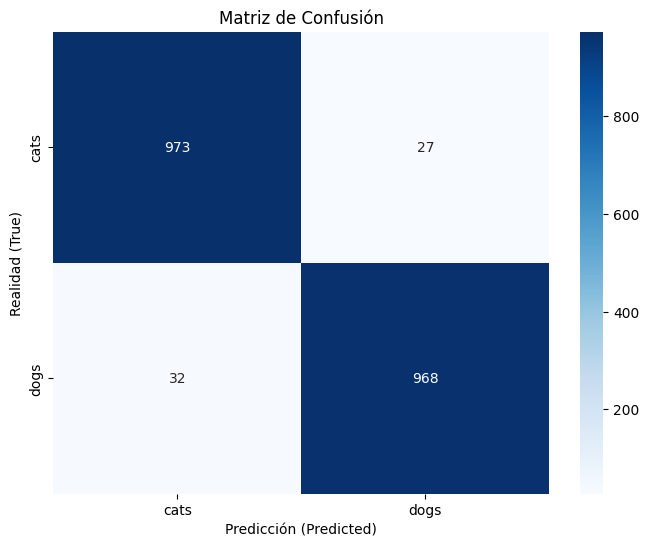

              precision    recall  f1-score   support

        cats       0.97      0.97      0.97      1000
        dogs       0.97      0.97      0.97      1000

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



In [42]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Recuperar los nombres de las clases del dataset ORIGINAL
# (Suponiendo que test_ds fue creado con image_dataset_from_directory)
labels_names = test_ds.class_names

# 2. Obtener las predicciones y las etiquetas reales de forma sincronizada
y_true = []
y_pred_probs = []

# Iteramos sobre el dataset limpio para asegurar que solo procesamos lo que NO está corrupto
for images, labels in test_ds_limpio:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds.ravel())

y_true = np.array(y_true)
y_pred = (np.array(y_pred_probs) > 0.5).astype(int)

# 3. Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_names,
            yticklabels=labels_names)
plt.title("Matriz de Confusión")
plt.ylabel("Realidad (True)")
plt.xlabel("Predicción (Predicted)")
plt.show()

# 4. Reporte de Clasificación (Precisión, Recall, F1)
print(classification_report(y_true, y_pred, target_names=labels_names))

Número total de imágenes mal clasificadas: 59


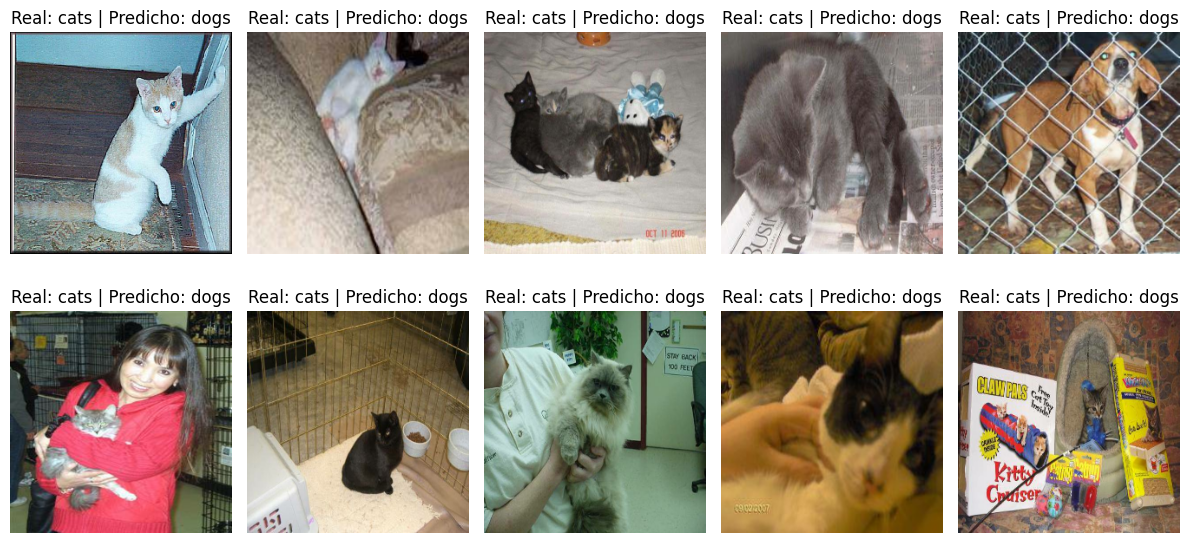

In [43]:
# Identificar los índices de las imágenes que se han clasificado incorrectamente
incorrect_indices = np.where(y_pred != y_true)[0]

print("Número total de imágenes mal clasificadas:", len(incorrect_indices))
num_show=10
index_show=incorrect_indices[:num_show]
single_element_ds = test_ds.unbatch()

# # Obtener la imagen en la posición 36 (indexada desde 0)

plt.figure(figsize=(12, 6))
for i in range(len(index_show)):
    index = index_show[i];
    imagen, etiqueta = list(single_element_ds.skip(index).take(1))[0]
    plt.subplot(2, (num_show + 1) // 2, i + 1)
    plt.imshow(imagen.numpy().astype("uint8"))
    plt.title(f"Real: {class_names[etiqueta]} | Predicho: {class_names[y_pred[index]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [44]:
import numpy as np
def classify(image_path):
  image = tf.keras.utils.load_img(image_path, color_mode='rgb')
  display(image)
  input_arr = tf.keras.utils.img_to_array(image)
  input_arr = np.array([input_arr])
  print(f'Tamaño de entrada: {input_arr.shape}')
  y_pred = model.predict(input_arr)
  print(f'Valores de salida: {y_pred[0][0]}')
  predicted_category_classname = class_names[round(y_pred[0][0])]
  print(f'Clasificación: {predicted_category_classname}')

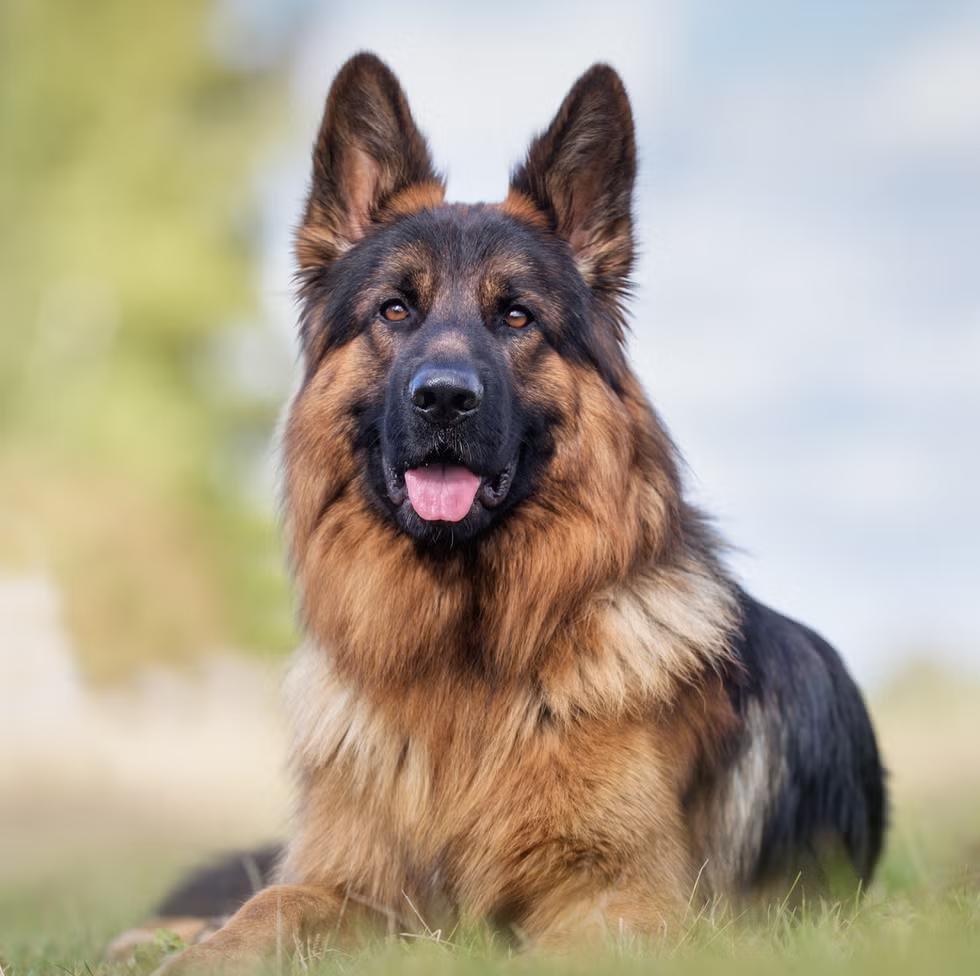

Tamaño de entrada: (1, 976, 980, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Valores de salida: 0.9998846054077148
Clasificación: dogs


In [53]:
classify('dog.jpg')